
# End-to-End Mini Project with NumPy, pandas, and Matplotlib

In this notebook we’ll go through a **small, realistic workflow** that shows how NumPy, pandas, and Matplotlib work **together**:

- Load a (mini) version of the **Titanic dataset** (very popular in ML).
- Explore and clean the data with **pandas**.
- Use **NumPy** for numeric operations and feature creation.
- Do some **basic feature engineering**.
- Visualize relationships using **Matplotlib**.

> In your actual session, you can replace the small in-notebook dataset with the full Titanic CSV from Kaggle; all the code will stay almost the same.


## 1. Imports and Settings

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For nicer plots in notebooks
%matplotlib inline
plt.style.use("seaborn-v0_8")

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)


NumPy: 2.3.5
pandas: 2.3.3



## 2. Load a Mini Titanic Dataset

We'll embed a small sample of the **Titanic** dataset directly as CSV text so this notebook is self-contained.

Columns used:

- `Survived`: 0 = No, 1 = Yes  
- `Pclass`: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)  
- `Sex`: Male / Female  
- `Age`: Age in years  
- `SibSp`: # of siblings / spouses aboard  
- `Parch`: # of parents / children aboard  
- `Fare`: Ticket fare  
- `Embarked`: Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)


In [2]:

from io import StringIO

csv_data = StringIO("""PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
1,0,3,male,22.0,1,0,7.25,S
2,1,1,female,38.0,1,0,71.2833,C
3,1,3,female,26.0,0,0,7.925,S
4,1,1,female,35.0,1,0,53.1,S
5,0,3,male,35.0,0,0,8.05,S
6,0,3,male,,0,0,8.4583,Q
7,0,1,male,54.0,0,0,51.8625,S
8,0,3,male,2.0,3,1,21.075,S
9,1,3,female,27.0,0,2,11.1333,S
10,1,2,female,14.0,1,0,30.0708,C
11,1,3,female,4.0,1,1,16.7,S
12,1,1,female,58.0,0,0,26.55,S
13,0,3,male,20.0,0,0,8.05,S
14,0,3,male,39.0,1,5,31.275,S
15,0,3,female,14.5,0,0,7.8542,S
16,1,2,female,55.0,0,0,16.0,S
17,0,3,male,2.0,4,1,29.125,Q
18,1,2,male,,0,0,13.0,S
19,0,3,female,31.0,1,0,18.0,S
20,1,3,female,18.0,0,0,7.775,S
""")

df = pd.read_csv(csv_data)
df.head()


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


## 3. First Look at the Data

In [3]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  20 non-null     int64  
 1   Survived     20 non-null     int64  
 2   Pclass       20 non-null     int64  
 3   Sex          20 non-null     object 
 4   Age          18 non-null     float64
 5   SibSp        20 non-null     int64  
 6   Parch        20 non-null     int64  
 7   Fare         20 non-null     float64
 8   Embarked     20 non-null     object 
dtypes: float64(2), int64(5), object(2)
memory usage: 1.5+ KB


In [5]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,20.00000,20.000000,20.000000,20,18.000000,20.000000,20.000000,20.000000,20
unique,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,female,NaN,NaN,NaN,NaN,S
freq,NaN,NaN,NaN,11,NaN,NaN,NaN,NaN,16
mean,10.50000,0.500000,2.450000,NaN,27.472222,0.700000,0.500000,22.226870,NaN
std,5.91608,0.512989,0.825578,NaN,17.387007,1.080935,1.192079,18.035288,NaN
min,1.00000,0.000000,1.000000,NaN,2.000000,0.000000,0.000000,7.250000,NaN
25%,5.75000,0.000000,2.000000,NaN,15.375000,0.000000,0.000000,8.050000,NaN
50%,10.50000,0.500000,3.000000,NaN,26.500000,0.000000,0.000000,16.350000,NaN
75%,15.25000,1.000000,3.000000,NaN,37.250000,1.000000,0.250000,29.361450,NaN



Observations:

- `Age` has some missing values (`NaN`).
- `Sex` and `Embarked` are **categorical** (string) columns.
- Numeric columns like `Age`, `Fare`, `SibSp`, `Parch` will be useful for feature engineering.


## 4. Using NumPy with pandas DataFrames


Even though we’re working with pandas, **NumPy is underneath**.

We can:

- Extract NumPy arrays from DataFrame columns  
- Perform NumPy operations and assign results back to new columns


In [6]:

# Extract NumPy array from a column
age_array = df["Age"].values
print(type(age_array))
print(age_array[:10])


<class 'numpy.ndarray'>
[22. 38. 26. 35. 35. nan 54.  2. 27. 14.]


In [7]:

# Compute a simple statistic using NumPy (ignoring NaNs)
mean_age = np.nanmean(age_array)   # nan-aware mean
median_age = np.nanmedian(age_array)

print("Mean age:", mean_age)
print("Median age:", median_age)


Mean age: 27.47222222222222
Median age: 26.5


### 4.1 Filling Missing Ages Using NumPy Computation

In [8]:

df["Age_filled"] = df["Age"].fillna(mean_age)
df[["Age", "Age_filled"]].head(10)


,Age,Age_filled
0,22.0,22.000000
1,38.0,38.000000
2,26.0,26.000000
3,35.0,35.000000
4,35.0,35.000000
5,NaN,27.472222
6,54.0,54.000000
7,2.0,2.000000
8,27.0,27.000000
9,14.0,14.000000


## 5. Basic Feature Engineering


We'll create a few **simple, realistic features**:

1. `FamilySize` – total number of immediate family members on board  
   \( \text{FamilySize} = \text{SibSp} + \text{Parch} + 1 \) (the `+1` is the passenger themself)  
2. `IsChild` – whether the passenger is a child (`Age_filled < 18`)  
3. `AgeGroup` – bucketed version of age (child, adult, senior)

These are the kind of transformations you do all the time before feeding data into an ML model.


In [9]:

# 1. FamilySize (using vectorized NumPy-style operations)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# 2. IsChild (True/False -> later can be converted to 0/1)
df["IsChild"] = df["Age_filled"] < 18

# 3. AgeGroup using pandas cut
bins = [0, 12, 18, 60, 100]
labels = ["Child", "Teen", "Adult", "Senior"]
df["AgeGroup"] = pd.cut(df["Age_filled"], bins=bins, labels=labels, right=False)

df.head(10)


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Age_filled,FamilySize,IsChild,AgeGroup
0,1,0,3,male,22.0,1,0,7.2500,S,22.000000,2,False,Adult
1,2,1,1,female,38.0,1,0,71.2833,C,38.000000,2,False,Adult
2,3,1,3,female,26.0,0,0,7.9250,S,26.000000,1,False,Adult
3,4,1,1,female,35.0,1,0,53.1000,S,35.000000,2,False,Adult
4,5,0,3,male,35.0,0,0,8.0500,S,35.000000,1,False,Adult
5,6,0,3,male,NaN,0,0,8.4583,Q,27.472222,1,False,Adult
6,7,0,1,male,54.0,0,0,51.8625,S,54.000000,1,False,Adult
7,8,0,3,male,2.0,3,1,21.0750,S,2.000000,5,True,Child
8,9,1,3,female,27.0,0,2,11.1333,S,27.000000,3,False,Adult
9,10,1,2,female,14.0,1,0,30.0708,C,14.000000,2,True,Teen


### 5.1 Simple Encoding: Map Sex/Gender to 0/1

In [10]:

# We'll map: male -> 0, female -> 1
df["Sex_num"] = df["Sex"].map({"male": 0, "female": 1})
df[["Sex", "Sex_num"]].head()


,Sex,Sex_num
0,male,0
1,female,1
2,female,1
3,female,1
4,male,0


## 6. Quick Exploratory Data Analysis (EDA) with pandas + NumPy

In [11]:

# Survival rate overall
survival_rate = df["Survived"].mean()
print("Overall survival rate: {:.2f}%".format(survival_rate * 100))


Overall survival rate: 50.00%


In [12]:

# Survival rate by Sex
survival_by_sex = df.groupby("Sex")["Survived"].mean() * 100
survival_by_sex


Sex
female    81.818182
male      11.111111
Name: Survived, dtype: float64

In [13]:

# Survival rate by Pclass
survival_by_pclass = df.groupby("Pclass")["Survived"].mean() * 100
survival_by_pclass


Pclass
1     75.000000
2    100.000000
3     30.769231
Name: Survived, dtype: float64

In [14]:

# Survival rate by AgeGroup
survival_by_agegroup = df.groupby("AgeGroup")["Survived"].mean() * 100
survival_by_agegroup


/tmp/ipykernel_33382/2508233174.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_agegroup = df.groupby("AgeGroup")["Survived"].mean() * 100


AgeGroup
Child     33.333333
Teen      50.000000
Adult     53.333333
Senior          NaN
Name: Survived, dtype: float64

## 7. Visualizing with Matplotlib


We’ll use Matplotlib to visualize:

1. Distribution of ages  
2. Survival counts by sex  
3. Survival rate by passenger class  
4. Relationship between fare and family size


### 7.1 Age Distribution

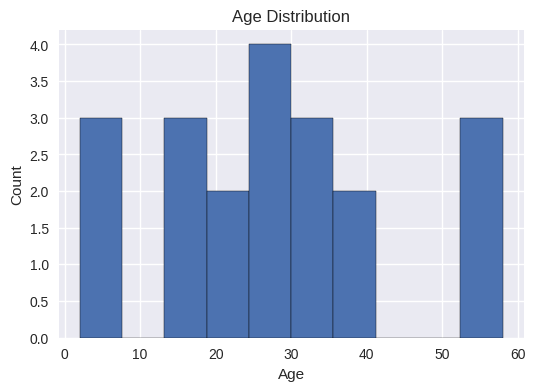

In [15]:

plt.figure(figsize=(6,4))
plt.hist(df["Age_filled"], bins=10, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


### 7.2 Survival Rate by Sex

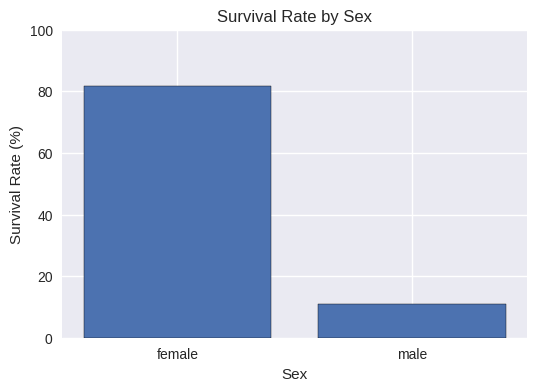

In [16]:

# Use the precomputed survival_by_sex Series
plt.figure(figsize=(6,4))
plt.bar(survival_by_sex.index, survival_by_sex.values, edgecolor="black")
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.show()


### 7.3 Survival Rate by Passenger Class (Pclass)

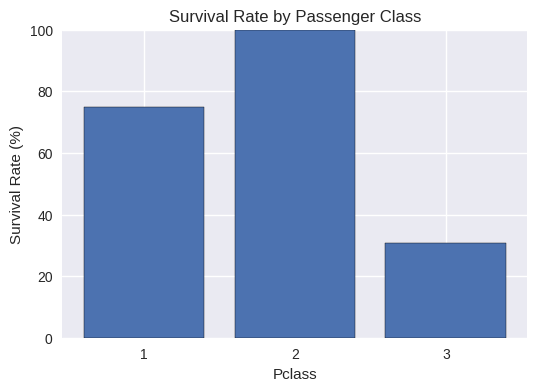

In [17]:

plt.figure(figsize=(6,4))
x_pos = np.arange(len(survival_by_pclass.index))
plt.bar(x_pos, survival_by_pclass.values, tick_label=survival_by_pclass.index, edgecolor="black")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Pclass")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.show()


### 7.4 Fare vs. Family Size (Scatter Plot)

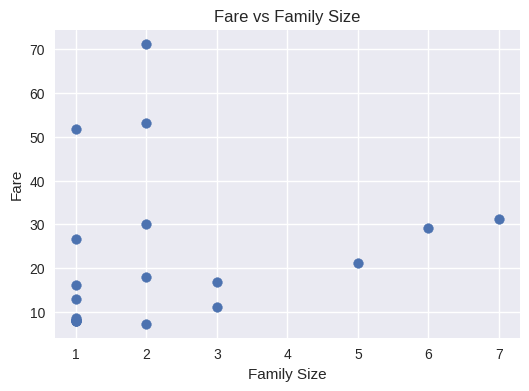

In [18]:

plt.figure(figsize=(6,4))
plt.scatter(df["FamilySize"], df["Fare"])
plt.title("Fare vs Family Size")
plt.xlabel("Family Size")
plt.ylabel("Fare")
plt.show()


## 8. Correlation with NumPy and pandas


We can compute correlations to see how numeric features relate to `Survived`.

This is not a full ML model, but it gives intuition about which features might be useful.


In [19]:

numeric_cols = ["Survived", "Pclass", "Age_filled", "SibSp", "Parch", "Fare", "FamilySize", "Sex_num"]
corr = df[numeric_cols].corr()
corr


,Survived,Pclass,Age_filled,SibSp,Parch,Fare,FamilySize,Sex_num
Survived,1.000000,-0.434959,0.173113,-0.284747,-0.172133,0.177879,-0.285831,0.703526
Pclass,-0.434959,1.000000,-0.636788,0.159240,0.294134,-0.778246,0.291275,-0.243555
Age_filled,0.173113,-0.636788,1.000000,-0.555434,-0.047576,0.335977,-0.366129,0.114771
SibSp,-0.284747,0.159240,-0.555434,1.000000,0.245072,0.259791,0.765062,-0.257564
Parch,-0.172133,0.294134,-0.047576,0.245072,1.000000,0.056973,0.811814,-0.216250
Fare,0.177879,-0.778246,0.335977,0.259791,0.056973,1.000000,0.194310,0.125188
FamilySize,-0.285831,0.291275,-0.366129,0.765062,0.811814,0.194310,1.000000,-0.298762
Sex_num,0.703526,-0.243555,0.114771,-0.257564,-0.216250,0.125188,-0.298762,1.000000


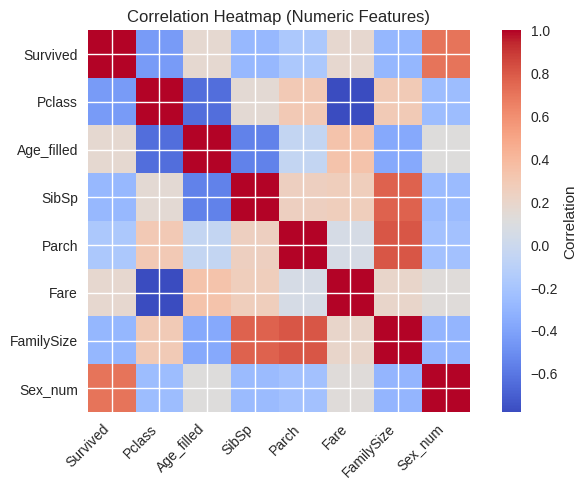

In [20]:

plt.figure(figsize=(7,5))
plt.imshow(corr, cmap="coolwarm", interpolation="none")
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


## 9. Mini Exercises for Students


Try these on your own (then you can create a new cell and check the solution ideas below):

1. **Create a new feature** `FarePerPerson` = `Fare` / `FamilySize`.  
2. Plot a **histogram** of `FarePerPerson`.  
3. Compute survival rate for **passengers traveling alone** (`FamilySize == 1`) vs **with family** (`FamilySize > 1`).  
4. Create a **bar chart** of survival rate by `Embarked`.  
5. Use `np.where` to create a numeric `IsChild_num` column (1 if `IsChild` is True, else 0).


### Example Solutions (One Possible Way)

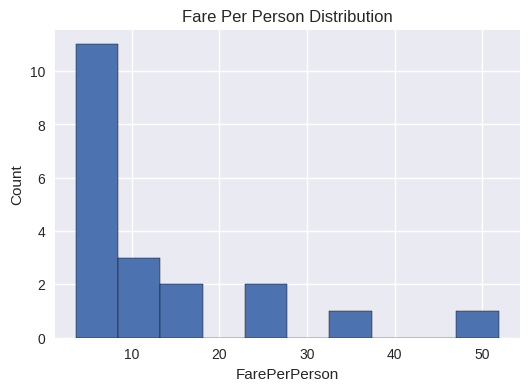

Survival rate (alone): 50.00%
Survival rate (with family): 50.00%


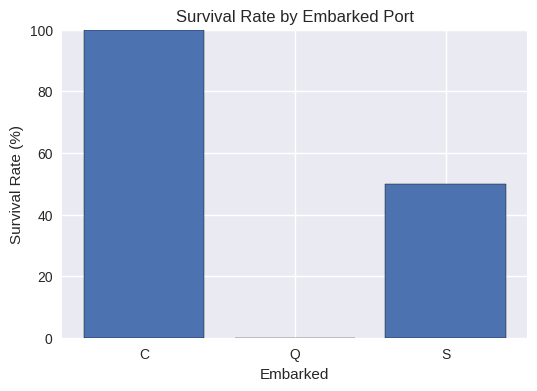

,IsChild,IsChild_num
0,False,0
1,False,0
2,False,0
3,False,0
4,False,0


In [21]:

# 1. FarePerPerson
df["FarePerPerson"] = df["Fare"] / df["FamilySize"]

# 2. Histogram of FarePerPerson
plt.figure(figsize=(6,4))
plt.hist(df["FarePerPerson"], bins=10, edgecolor="black")
plt.title("Fare Per Person Distribution")
plt.xlabel("FarePerPerson")
plt.ylabel("Count")
plt.show()

# 3. Survival rate alone vs with family
alone = df["FamilySize"] == 1
with_family = df["FamilySize"] > 1

survival_alone = df.loc[alone, "Survived"].mean() * 100
survival_family = df.loc[with_family, "Survived"].mean() * 100

print("Survival rate (alone): {:.2f}%".format(survival_alone))
print("Survival rate (with family): {:.2f}%".format(survival_family))

# 4. Survival rate by Embarked
survival_by_embarked = df.groupby("Embarked")["Survived"].mean() * 100

plt.figure(figsize=(6,4))
plt.bar(survival_by_embarked.index, survival_by_embarked.values, edgecolor="black")
plt.title("Survival Rate by Embarked Port")
plt.xlabel("Embarked")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.show()

# 5. IsChild_num using np.where
df["IsChild_num"] = np.where(df["IsChild"], 1, 0)
df[["IsChild", "IsChild_num"]].head()
